In [1]:
%pip install "ncrystal[plot]" "git+https://github.com/XuShuqi7/ncplugin-CrysExtn"

  Cloning https://github.com/XuShuqi7/ncplugin-CrysExtn to /tmp/pip-req-build-6t0fxh24
  Running command git clone --filter=blob:none --quiet https://github.com/XuShuqi7/ncplugin-CrysExtn /tmp/pip-req-build-6t0fxh24
  Resolved https://github.com/XuShuqi7/ncplugin-CrysExtn to commit 4213dabdaff68b09fe80c18ecb70db90c12a08bc
ERROR: git+https://github.com/XuShuqi7/ncplugin-CrysExtn does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
Note: you may need to restart the kernel to use updated packages.


In [9]:
import NCrystal as NC
import numpy as np
import matplotlib.pyplot as plt

In [10]:
wavelength = np.linspace(0,5,10000)
E = NC.wl2ekin(wavelength)

In [4]:
Be = NC.createScatter('stdlib::Be_sg194.ncmat')
xs = Be.crossSectionIsotropic(E)

In [6]:
Be_m = NC.createScatter('plugins::CrysExtn/Be_sg194_BC_mix.ncmat')
xs_m = Be_m.crossSectionIsotropic(E)

NCrystal WARNING: Loading NCMAT data which has @CUSTOM_ section(s). This is OK if intended.


In [7]:
Be_s = NC.createScatter('plugins::CrysExtn/Be_sg194_BC_pure_scndI.ncmat')
xs_s = Be_s.crossSectionIsotropic(E)

NCrystal WARNING: Loading NCMAT data which has @CUSTOM_ section(s). This is OK if intended.


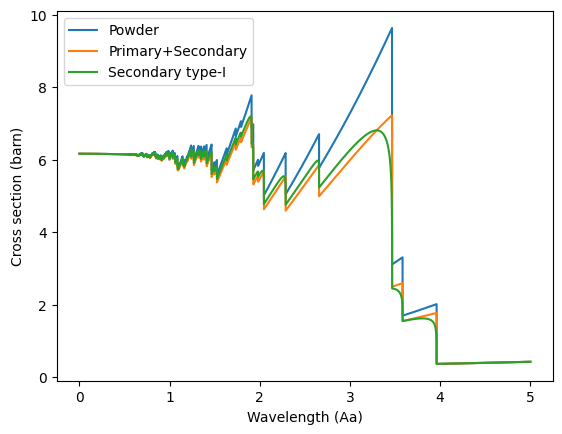

In [8]:
fig, ax = plt.subplots()
ax.plot(wavelength, xs,   label='Powder')
ax.plot(wavelength, xs_m, label='Primary+Secondary')
ax.plot(wavelength, xs_s, label='Secondary type-I')

ax.set(xlabel='Wavelength (Aa)', ylabel='Cross section (barn)')
ax.legend()

plt.show()